<a href="https://colab.research.google.com/github/AbdulrahmanB-25/Apply_Compare_Clustering_Algorithms/blob/main/Clustering_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kagglehub[pandas-datasets]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "vjchoudhary7/customer-segmentation-tutorial-in-python",
    "Mall_Customers.csv"
)
df.head()

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()
print(df.isnull().sum().sum(), 'missing values')
print(df.duplicated().sum(), 'duplicates')
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
0 missing values
0 duplicates


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Elbow method to pick K
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Fit final model
kmeans = KMeans(n_clusters=6, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

In [ ]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

In [ ]:
hc = AgglomerativeClustering(n_clusters=4)
y_hc = hc.fit_predict(X_scaled)

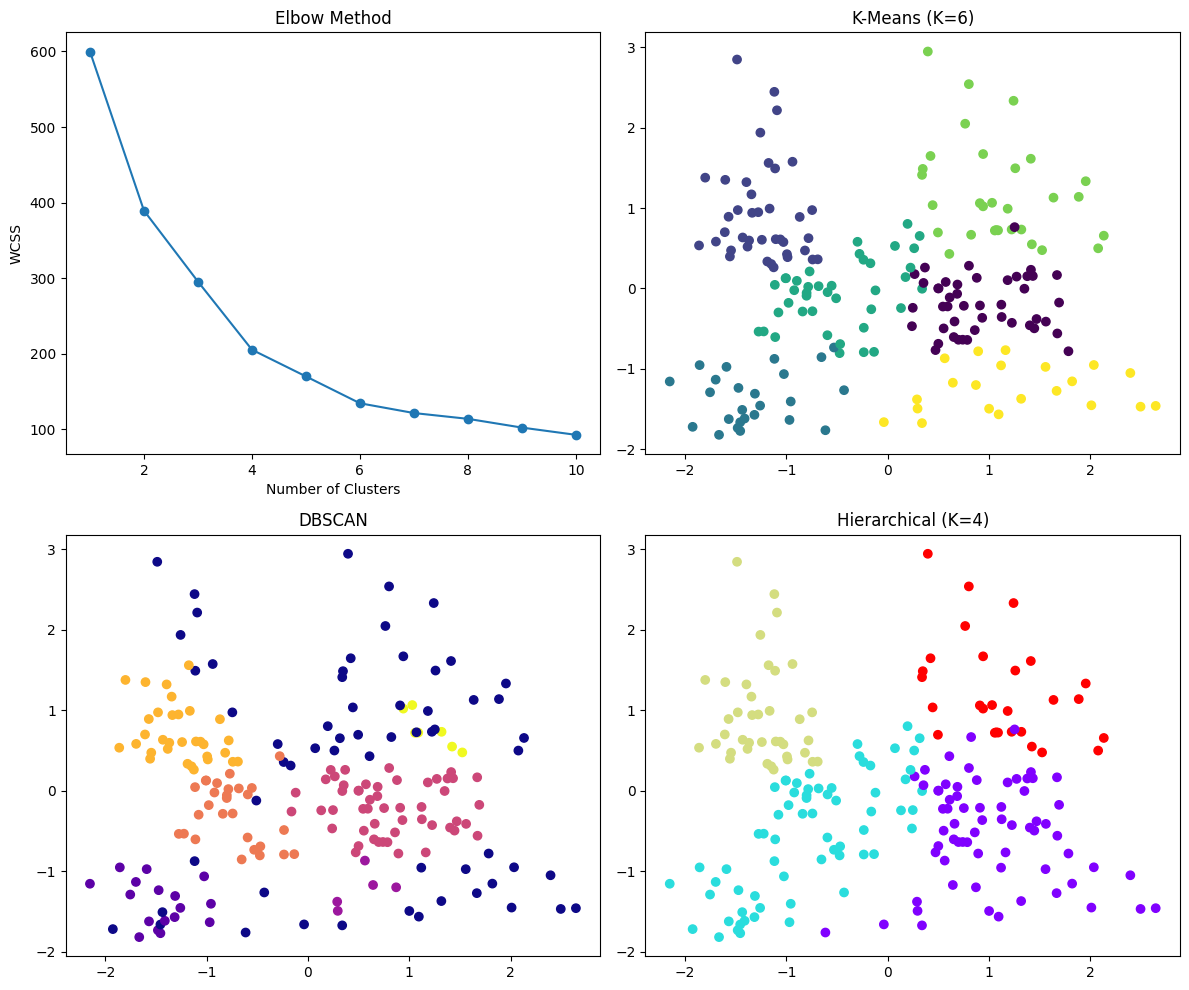

In [ ]:
X_pca = PCA(n_components=2).fit_transform(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Elbow
axes[0, 0].plot(range(1, 11), wcss, marker='o')
axes[0, 0].set_title('Elbow Method')
axes[0, 0].set_xlabel('Number of Clusters')
axes[0, 0].set_ylabel('WCSS')

# K-Means
axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis')
axes[0, 1].set_title('K-Means (K=6)')

# DBSCAN
axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_dbscan, cmap='plasma')
axes[1, 0].set_title('DBSCAN')

# Hierarchical
axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_hc, cmap='rainbow')
axes[1, 1].set_title('Hierarchical (K=4)')

plt.tight_layout()
plt.show()

In [ ]:
score_kmeans  = silhouette_score(X_scaled, y_kmeans)
score_hc      = silhouette_score(X_scaled, y_hc)
mask = y_dbscan != -1
score_dbscan  = silhouette_score(X_scaled[mask], y_dbscan[mask])

print(f'K-Means      | clusters: 6 | silhouette: {score_kmeans:.4f}')
print(f'Hierarchical | clusters: 4 | silhouette: {score_hc:.4f}')
print(f'DBSCAN       | clusters: {len(set(y_dbscan)) - 1} | noise: {list(y_dbscan).count(-1)} | silhouette: {score_dbscan:.4f}')

K-Means      | clusters: 6 | silhouette: 0.4311
Hierarchical | clusters: 4 | silhouette: 0.3615
DBSCAN       | clusters: 6 | noise: 60 | silhouette: 0.4817


## Critical Thinking

**Which algorithm performed best?**  
DSCAN.

**When would you use each?**  
- **K-Means** — data with clear round clusters, known K  
- **DBSCAN** — noisy data, unknown K, irregular shapes  
- **Hierarchical** — small datasets, need to explore different K values  

**Strengths & Weaknesses**  
- **K-Means**: fast, scalable ✅ — needs K upfront, assumes spherical clusters ❌  
- **DBSCAN**: handles noise & arbitrary shapes ✅ — sensitive to eps/min_samples ❌  
- **Hierarchical**: no K needed, dendogram ✅ — slow on large data ❌